In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

c:\Users\Sreeansh Dash\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Load Dataset
Uses the local HuggingFace cache — no re-download needed.

In [2]:
ds = load_dataset("ekacare/NidaanKosha-100k-V1.0")
df = ds["train"].to_pandas()
print(f"Raw shape: {df.shape}")

Raw shape: (6844304, 9)


## Step 2 — Keep Blood Specimen Only
The dataset includes urine, stool, and other specimen types.  
We only want blood tests for this project.

In [3]:
print("Specimen types and counts:")
print(df["specimen"].value_counts())

# Keep only blood-related specimens
blood_keywords = ["blood", "serum", "plasma", "whole blood"]
df = df[df["specimen"].str.lower().str.contains("|".join(blood_keywords), na=False)]

print(f"\nAfter blood filter: {df.shape}")

Specimen types and counts:
specimen
blood          5436575
urine           998723
stool             4833
pus                973
body_fluid         763
respiratory        603
patient            493
semen              438
tissue             113
urine_24h           54
eye_swab             9
ear_swab             1
Name: count, dtype: int64

After blood filter: (5436575, 9)


## Step 3 — LOINC-Based Column Standardization
The same test can appear under many different names across labs  
(e.g., "Haemoglobin", "Hb", "HGB" are all the same test).  
LOINC codes are internationally standardized — we use them as column identifiers,  
then map back a clean readable name for display.

In [4]:
# Drop rows with no LOINC code (can't standardize these)
before = len(df)
df = df.dropna(subset=["loinc"])
print(f"Dropped {before - len(df):,} rows with missing LOINC. Remaining: {len(df):,}")

# How many unique LOINC codes?
print(f"Unique LOINC codes: {df['loinc'].nunique()}")

Dropped 178,156 rows with missing LOINC. Remaining: 5,258,419
Unique LOINC codes: 379


In [5]:
# Build a LOINC → readable name mapping.
# For each LOINC code, take the most frequent test_name as the "canonical" name.
loinc_name_map = (
    df.groupby("loinc")["test_name"]
    .agg(lambda x: x.value_counts().index[0])  # most common name for this code
    .to_dict()
)

# Add a standardized column using LOINC code
df["loinc_name"] = df["loinc"].map(loinc_name_map)

print("Sample LOINC → name mappings:")
for k, v in list(loinc_name_map.items())[:10]:
    print(f"  {k}  →  {v}")

Sample LOINC → name mappings:
  101206-1  →  DENGUE FEVER ANTIGEN NS1 EIA
  10331-7  →  Rh TYPING
  10334-1  →  CA 125; OVARIAN CANCER MARKER, SERUM
  10378-8  →  Polychromasia
  10501-5  →  LH
  10710-2  →  THIN SMEAR
  10835-7  →  Lipoprotein a
  10886-0  →  Free-PSA (Prostate Specific Antigen)
  11039-5  →  C-Reactive Protein (Qualitative)
  11054-4  →  LDL / HDL RATIO


## Step 4 — Select Top Tests by Patient Coverage
With 581 unique LOINC codes, a full pivot would be extremely sparse.  
We keep only tests that appear in at least **20% of patients** (~20,000 patients).  
This gives us a denser, more useful feature matrix.

In [6]:
total_patients = df["document_id"].nunique()
min_coverage = 0.20   # keep tests present in at least 20% of patients

# Count how many patients have each LOINC test
loinc_coverage = (
    df.groupby("loinc")["document_id"]
    .nunique()
    .sort_values(ascending=False)
)

# Filter
selected_loincs = loinc_coverage[loinc_coverage >= min_coverage * total_patients].index.tolist()

print(f"Total LOINC codes     : {len(loinc_coverage)}")
print(f"After 20% filter      : {len(selected_loincs)}")
print(f"\nSelected tests:")
for loinc in selected_loincs:
    name = loinc_name_map.get(loinc, loinc)
    pct = loinc_coverage[loinc] / total_patients * 100
    print(f"  {loinc:15s}  {name:30s}  {pct:.1f}% of patients")

Total LOINC codes     : 379
After 20% filter      : 68

Selected tests:
  2093-3           TOTAL CHOLESTEROL               99.8% of patients
  718-7            Hemoglobin                      99.7% of patients
  26464-8          Total WBC Count                 97.8% of patients
  26515-7          Platelet Count                  97.3% of patients
  26478-8          Lymphocytes                     97.3% of patients
  26453-1          RBC Count                       97.1% of patients
  2571-8           Triglycerides                   97.0% of patients
  26450-7          Eosinophils                     96.6% of patients
  26485-3          Monocytes                       96.5% of patients
  2085-9           HDL Cholesterol                 95.7% of patients
  30428-7          MCV                             95.2% of patients
  28539-5          MCH                             95.1% of patients
  2089-1           LDL Cholesterol                 95.0% of patients
  30180-4          Basophils   

In [7]:
# Keep only selected tests
df_filtered = df[df["loinc"].isin(selected_loincs)].copy()
print(f"Filtered long-format shape: {df_filtered.shape}")

Filtered long-format shape: (4837888, 10)


In [8]:
# These are the LOINC codes confirmed to have unit mixing issues

problematic_loincs = {
    "26515-7": "Platelet Count",
    "26464-8": "Total WBC Count",
    "26499-4": "Absolute Neutrophil Count",
    "26474-7": "Absolute Lymphocyte Count",
    "26484-6": "Absolute Monocyte Count",
    "26449-9": "Absolute Eosinophil Count",
    "26444-0": "Absolute Basophil Count",
    "51637-7": "PCT (Plateletcrit)",
}

# Convert value to numeric here since Step 5 hasn't run yet
df_filtered["value"] = pd.to_numeric(df_filtered["value"], errors="coerce")
for loinc, name in problematic_loincs.items():
    subset = df_filtered[df_filtered["loinc"] == loinc]
    print(f"\n{'='*60}")
    print(f"{name} ({loinc}) — {len(subset):,} rows")
    print("Unit counts:")
    print(subset["unit"].value_counts().head(10).to_string())
    print("Value stats:")
    print(subset["value"].describe().round(2).to_string())


Platelet Count (26515-7) — 97,318 rows
Unit counts:
unit
10^3/ul        11361
thou/mm3        6698
10^3/uL         6480
Thousand/uL     4571
thousand/uL     4516
10^3 / ul       4052
X 10 ³ / uL     3925
thou/uL         3369
/cmm            2973
X 10^3/ul       2804
Value stats:
count       95780.00
mean        36621.31
std        148401.80
min             0.00
25%           189.00
50%           259.00
75%           340.00
max      24800000.00

Total WBC Count (26464-8) — 97,773 rows
Unit counts:
unit
cells/cumm         11680
cells/cu.mm        10347
10^3/ul             8477
thou/mm3            6387
10^3/uL             6246
X 10 ³ / uL         4149
/cmm                3328
/cumm               2902
X 10 superscrip     2743
thou/uL             2514
Value stats:
count      97554.00
mean        4223.02
std        22725.15
min            0.00
25%            7.00
50%           11.90
75%         7100.00
max      1123000.00

Absolute Neutrophil Count (26499-4) — 82,781 rows
Unit counts:
unit


In [9]:
# Rules: (loinc, standard_max, conversion_factor, description)
# If value > standard_max → it's on the large scale → multiply by conversion_factor
# standard_max is set between the two scales to cleanly separate them

normalization_rules = {
    # Platelet: ×10³/µL (150-400) vs /µL (150,000-400,000)
    # threshold = 5000: anything above is in /µL → divide by 1000
    "26515-7": {"name": "Platelet Count",               "threshold": 5000,  "factor": 1/1000},

    # Total WBC: ×10³/µL (4-10) vs cells/cumm (4000-10000)
    # threshold = 100: anything above is in cells/µL → divide by 1000
    "26464-8": {"name": "Total WBC Count",              "threshold": 100,   "factor": 1/1000},

    # Absolute Neutrophil: ×10³/µL (2-7) vs cells/µL (2000-7000)
    "26499-4": {"name": "Absolute Neutrophil Count",    "threshold": 100,   "factor": 1/1000},

    # Absolute Lymphocyte: ×10³/µL (1-3) vs cells/µL (1000-3000)
    "26474-7": {"name": "Absolute Lymphocyte Count",    "threshold": 100,   "factor": 1/1000},

    # Absolute Monocyte: ×10³/µL (0.2-1.0) vs cells/µL (200-1000)
    "26484-6": {"name": "Absolute Monocyte Count",      "threshold": 50,    "factor": 1/1000},

    # Absolute Eosinophil: ×10³/µL (0.02-0.5) vs cells/µL (20-500)
    "26449-9": {"name": "Absolute Eosinophil Count",    "threshold": 10,    "factor": 1/1000},

    # Absolute Basophil: ×10³/µL (0.01-0.1) vs cells/µL (10-100)
    "26444-0": {"name": "Absolute Basophil Count",      "threshold": 5,     "factor": 1/1000},
}

# PCT is excluded — two conflicting reference ranges found on site,
# suggesting extraction errors. Will drop it as unreliable.
PCT_LOINC = "51637-7"
print("Normalization rules defined.")
print(f"PCT ({PCT_LOINC}) will be dropped as unreliable.")

Normalization rules defined.
PCT (51637-7) will be dropped as unreliable.


In [10]:
import copy

df_normalized = df_filtered.copy()
conversion_log = []

for loinc, rule in normalization_rules.items():
    mask_loinc = df_normalized["loinc"] == loinc
    mask_high  = df_normalized["value"] > rule["threshold"]
    mask_both  = mask_loinc & mask_high

    n_converted = mask_both.sum()
    n_total     = mask_loinc.sum()

    if n_converted > 0:
        df_normalized.loc[mask_both, "value"] = (
            df_normalized.loc[mask_both, "value"] * rule["factor"]
        )

    conversion_log.append({
        "test"         : rule["name"],
        "loinc"        : loinc,
        "total_rows"   : n_total,
        "converted"    : n_converted,
        "pct_converted": round(n_converted / n_total * 100, 1) if n_total > 0 else 0
    })

log_df = pd.DataFrame(conversion_log)
print("Conversion summary:")
print(log_df.to_string(index=False))

Conversion summary:
                     test   loinc  total_rows  converted  pct_converted
           Platelet Count 26515-7       97318      12984           13.3
          Total WBC Count 26464-8       97773      47329           48.4
Absolute Neutrophil Count 26499-4       82781      34998           42.3
Absolute Lymphocyte Count 26474-7       82898      37028           44.7
  Absolute Monocyte Count 26484-6       82627      35250           42.7
Absolute Eosinophil Count 26449-9       83377      32123           38.5
  Absolute Basophil Count 26444-0       79274      21087           26.6


In [11]:
# Drop PCT — confirmed unreliable
before = len(df_normalized)
df_normalized = df_normalized[df_normalized["loinc"] != PCT_LOINC]
print(f"Dropped PCT rows: {before - len(df_normalized):,}")
print(f"Remaining: {len(df_normalized):,}")

Dropped PCT rows: 49,769
Remaining: 4,788,119


In [12]:
# After normalization, all values for these tests should be in the standard range
print("Post-normalization value ranges (should now be in ×10³/µL scale):\n")
for loinc, rule in normalization_rules.items():
    vals = df_normalized[df_normalized["loinc"] == loinc]["value"]
    if len(vals) == 0:
        continue
    p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
    print(f"{rule['name']:40s}  p1={p1:.3f}  median={vals.median():.3f}  p99={p99:.3f}")

Post-normalization value ranges (should now be in ×10³/µL scale):

Platelet Count                            p1=1.660  median=244.000  p99=482.000
Total WBC Count                           p1=0.669  median=7.100  p99=14.200
Absolute Neutrophil Count                 p1=0.302  median=4.005  p99=14.924
Absolute Lymphocyte Count                 p1=0.164  median=2.268  p99=7.000
Absolute Monocyte Count                   p1=0.053  median=0.400  p99=47.000
Absolute Eosinophil Count                 p1=0.030  median=0.218  p99=1.570
Absolute Basophil Count                   p1=0.000  median=0.020  p99=0.128


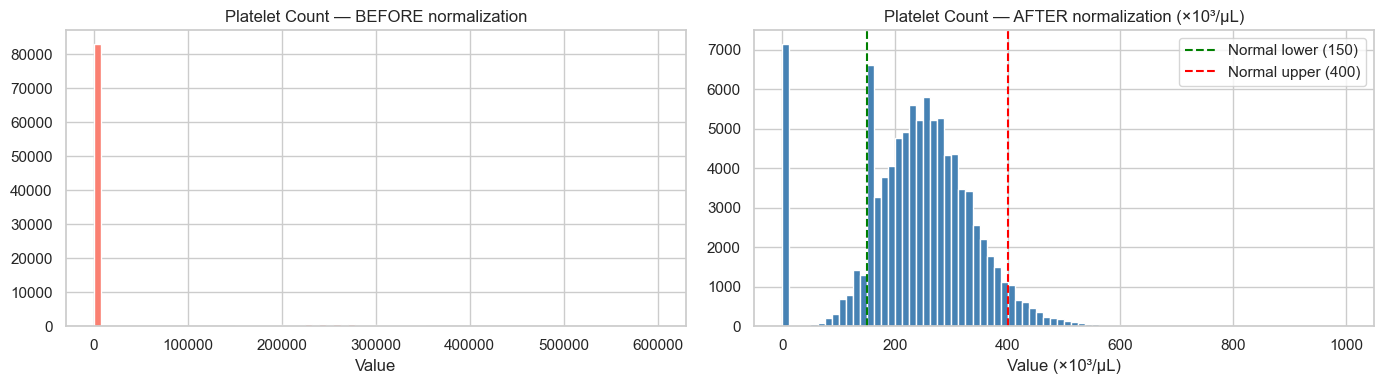

In [13]:
# Visual check: before vs after for platelet count
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before (from df_filtered)
before_vals = df_filtered[df_filtered["loinc"] == "26515-7"]["value"].dropna()
before_vals.clip(0, 600000).hist(bins=80, ax=axes[0], color="salmon", edgecolor="white")
axes[0].set_title("Platelet Count — BEFORE normalization")
axes[0].set_xlabel("Value")

# After
after_vals = df_normalized[df_normalized["loinc"] == "26515-7"]["value"].dropna()
after_vals.clip(0, 1000).hist(bins=80, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Platelet Count — AFTER normalization (×10³/µL)")
axes[1].set_xlabel("Value (×10³/µL)")
axes[1].axvline(150, color="green", linestyle="--", label="Normal lower (150)")
axes[1].axvline(400, color="red", linestyle="--", label="Normal upper (400)")
axes[1].legend()

plt.tight_layout()
plt.savefig("./results/plots/platelet_normalization_check.png", dpi=150)
plt.show()

In [14]:
# Replace df_filtered with the normalized version for the rest of preprocessing
df_filtered = df_normalized
print("df_filtered updated with normalized units.")
print(f"Shape: {df_filtered.shape}")
print("\nContinue from Step 5 (Select top tests) onwards.")

df_filtered updated with normalized units.
Shape: (4788119, 10)

Continue from Step 5 (Select top tests) onwards.


## Step 5 — Handle Duplicate Readings
Some patients have multiple readings for the same test in one report  
(e.g., duplicate rows, or pre/post measurements).  
We take the **mean** of duplicates — a reasonable middle ground.

In [15]:
# Check how many duplicates exist
dupes = df_filtered.duplicated(subset=["document_id", "loinc"]).sum()
print(f"Duplicate (patient, test) pairs: {dupes:,}")

# Convert value column to numeric first (some might be strings)
df_filtered["value"] = pd.to_numeric(df_filtered["value"], errors="coerce")

# Drop rows where value couldn't be converted to a number
df_filtered = df_filtered.dropna(subset=["value"])
print(f"After dropping non-numeric values: {df_filtered.shape}")

Duplicate (patient, test) pairs: 0
After dropping non-numeric values: (4774599, 10)


## Step 6 — Long → Wide Pivot
This is the core reshape step.  
`pivot_table` creates one row per patient, one column per LOINC test.  
`aggfunc="mean"` handles duplicates automatically.

In [16]:
# Pivot: index = patient, columns = loinc code, values = test result
wide = df_filtered.pivot_table(
    index="document_id",
    columns="loinc",
    values="value",
    aggfunc="mean"
)

# Rename columns from LOINC codes to readable names
wide.columns = [loinc_name_map.get(c, c) for c in wide.columns]
wide.columns.name = None   # remove the "loinc" label from column axis
wide = wide.reset_index()

print(f"Wide format shape: {wide.shape}")
print(f"  → {wide.shape[0]:,} patients × {wide.shape[1]-1} tests")
wide.head()

Wide format shape: (99992, 68)
  → 99,992 patients × 67 tests


,document_id,LDL / HDL RATIO,Glucose Fasting,SGPT (ALT),Albumin,A/G Ratio,CALCIUM,AST/ALT Ratio,ASPARTATE AMINOTRANSFERASE (SGOT ),Bilirubin Direct,...,Non HDL Cholesterol,HbA1c,PLATELET TO LARGE CELL RATIO(PLCR),Platelet distribution width-CV,Neutrophils,25-OH VITAMIN D (TOTAL),ALKALINE PHOSPHATASE,EST. GLOMERULAR FILTRATION RATE (eGFR),Hemoglobin,TC/ HDL CHOLESTEROL RATIO
0,0000dc1043b556f847b88a34a1875b26,2.31,165.9,29.30,4.62,1.42,9.7,NaN,45.30,0.13,...,138.8,7.1,NaN,17.5,64.6,NaN,146.00,141.56,11.1,3.79
1,000219ef567ad65827350691e2776022,2.10,90.0,17.00,4.40,1.80,9.6,1.0,17.00,0.30,...,146.0,6.2,NaN,NaN,48.0,18.3,82.00,NaN,14.0,3.40
2,00035a9874991a7860f448275b54f05d,NaN,NaN,19.98,3.78,1.83,NaN,NaN,26.54,0.24,...,NaN,NaN,20.6,14.9,NaN,NaN,60.17,NaN,11.8,NaN
3,00037a26c47df4123bcaeda56a0e13c8,NaN,NaN,16.00,4.40,1.69,8.7,NaN,23.00,0.30,...,NaN,NaN,NaN,NaN,54.0,NaN,88.00,NaN,13.2,NaN
4,0003b1d0154a792cf85a281ebd74c973,2.40,NaN,11.00,3.70,1.10,9.0,NaN,17.00,0.10,...,NaN,5.5,NaN,NaN,64.0,NaN,85.00,NaN,11.4,4.50


## Step 7 — Add Demographics Back
The pivot dropped age and gender. We merge them back in from the original data.

In [17]:
# One row per patient with demographics
demographics = (
    df[["document_id", "age", "gender"]]
    .drop_duplicates(subset="document_id")
)

wide = wide.merge(demographics, on="document_id", how="left")
print(f"Shape after adding demographics: {wide.shape}")
wide[["document_id", "age", "gender"]].head()

Shape after adding demographics: (99992, 70)


,document_id,age,gender
0,0000dc1043b556f847b88a34a1875b26,45,female
1,000219ef567ad65827350691e2776022,36,male
2,00035a9874991a7860f448275b54f05d,26,female
3,00037a26c47df4123bcaeda56a0e13c8,19,male
4,0003b1d0154a792cf85a281ebd74c973,57,female


## Step 8 — Missing Value Analysis & Drop Sparse Columns
Even after filtering to top tests, some columns may still be very sparse.

Missing % per test column:
Platelet distribution width-CV        78.5
Iron                                  71.7
PLATELET TO LARGE CELL RATIO(PLCR)    71.6
% TRANSFERRIN SATURATION              67.3
AST/ALT Ratio                         64.2
                                      ... 
RBC Count                              3.1
Lymphocytes                            3.1
Total WBC Count                        2.4
Hemoglobin                             0.5
TOTAL CHOLESTEROL                      0.4
Length: 67, dtype: float64


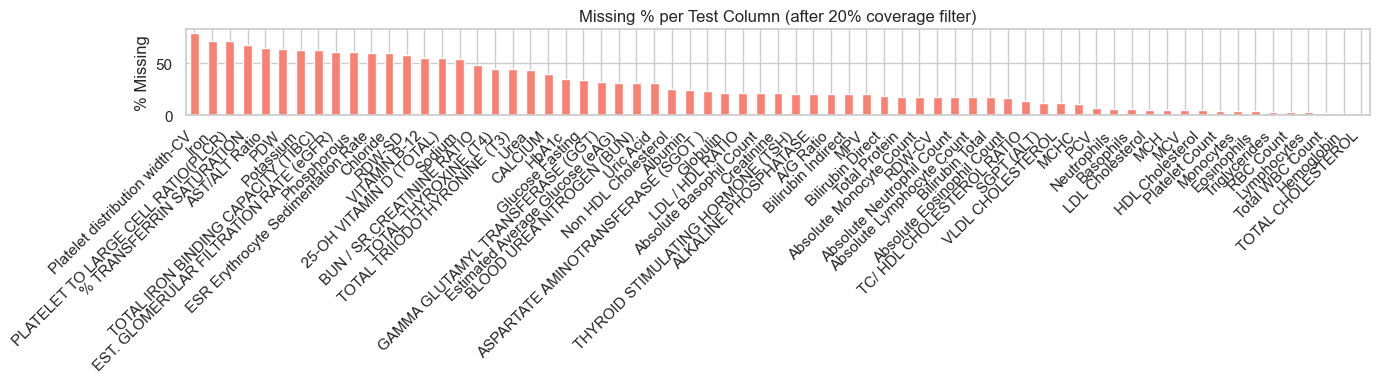

In [18]:
# % missing per column (excluding id, age, gender)
feature_cols = [c for c in wide.columns if c not in ["document_id", "age", "gender"]]
missing_pct = wide[feature_cols].isnull().mean() * 100

print("Missing % per test column:")
print(missing_pct.sort_values(ascending=False).round(1))

plt.figure(figsize=(14, 4))
missing_pct.sort_values(ascending=False).plot(kind="bar", color="salmon", edgecolor="white")
plt.title("Missing % per Test Column (after 20% coverage filter)")
plt.ylabel("% Missing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# Drop columns still missing > 60% of values
drop_threshold = 0.60
cols_to_drop = missing_pct[missing_pct > drop_threshold * 100].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >60% missing: {cols_to_drop}")

wide = wide.drop(columns=cols_to_drop)
feature_cols = [c for c in wide.columns if c not in ["document_id", "age", "gender"]]
print(f"Remaining feature columns: {len(feature_cols)}")

Dropping 10 columns with >60% missing: ['AST/ALT Ratio', 'Iron', 'TOTAL IRON BINDING CAPACITY (TIBC)', '% TRANSFERRIN SATURATION', 'Phosphorous', 'Potassium', 'PDW', 'PLATELET TO LARGE CELL RATIO(PLCR)', 'Platelet distribution width-CV', 'EST. GLOMERULAR FILTRATION RATE (eGFR)']
Remaining feature columns: 57


## Step 9 — Median Imputation
For remaining NaN values, we fill with the **column median**.  
Median is preferred over mean because blood test values often have outliers.

In [20]:
# Fill missing values with column median
wide[feature_cols] = wide[feature_cols].fillna(wide[feature_cols].median())

# Confirm no more nulls in feature columns
remaining_nulls = wide[feature_cols].isnull().sum().sum()
print(f"Null values remaining in features: {remaining_nulls}")

Null values remaining in features: 0


## Step 10 — Outlier Clipping (IQR Method)
Extreme outliers in lab data often indicate data entry errors  
(e.g., HbA1c = 999 or Hemoglobin = 0.01).  
We clip values to the **1st–99th percentile** per column.

In [21]:
for col in feature_cols:
    p01 = wide[col].quantile(0.01)
    p99 = wide[col].quantile(0.99)
    wide[col] = wide[col].clip(lower=p01, upper=p99)

print("Outlier clipping done (1st–99th percentile per column).")

Outlier clipping done (1st–99th percentile per column).


## Step 11 — Encode Gender
ML models need numbers, not strings. We encode gender as 0/1.

In [22]:
# Encode gender: Male = 1, Female = 0, unknown = NaN
wide["gender_enc"] = wide["gender"].map({"male": 1, "female": 0})

print(wide["gender_enc"].value_counts(dropna=False))

gender_enc
1    57340
0    42652
Name: count, dtype: int64


## Step 12 — Normalize Features (StandardScaler)
Different tests have very different scales (e.g., glucose ~5–20, WBC ~4000–11000).  
StandardScaler brings all features to mean=0, std=1.  
This is important for clustering and distance-based models.

In [23]:
scaler = StandardScaler()

# Columns to scale: numeric test values + age
cols_to_scale = feature_cols + ["age"]
cols_to_scale = [c for c in cols_to_scale if c in wide.columns]

wide_scaled = wide.copy()
wide_scaled[cols_to_scale] = scaler.fit_transform(wide[cols_to_scale])

print("Scaling done.")
print(wide_scaled[cols_to_scale].describe().round(2))

Scaling done.
       LDL / HDL RATIO  Glucose Fasting  SGPT (ALT)   Albumin  A/G Ratio  \
count         99992.00         99992.00    99992.00  99992.00   99992.00   
mean             -0.00            -0.00        0.00     -0.00      -0.00   
std               1.00             1.00        1.00      1.00       1.00   
min              -2.05            -0.98       -1.07     -3.12      -2.32   
25%              -0.58            -0.43       -0.59     -0.51      -0.56   
50%              -0.10            -0.29       -0.28      0.07      -0.08   
75%               0.46            -0.09        0.21      0.44       0.44   
max               3.20             5.04        4.80      2.55       3.36   

        CALCIUM  ASPARTATE AMINOTRANSFERASE (SGOT )  Bilirubin Direct  \
count  99992.00                            99992.00          99992.00   
mean       0.00                                0.00              0.00   
std        1.00                                1.00              1.00   
min      

## Step 13 — Save Outputs
- `wide_format.csv` — pivoted, imputed, clipped (raw scale, before normalization)  
- `cleaned.csv` — normalized version ready for clustering

In [24]:
import os
os.makedirs("./data/processed", exist_ok=True)

# Raw wide format (interpretable values)
wide.to_csv("./data/processed/wide_format.csv", index=False)

# Normalized (for ML)
wide_scaled.to_csv("./data/processed/cleaned.csv", index=False)

print(f"Saved wide_format.csv  — shape: {wide.shape}")
print(f"Saved cleaned.csv      — shape: {wide_scaled.shape}")

Saved wide_format.csv  — shape: (99992, 61)
Saved cleaned.csv      — shape: (99992, 61)


## Summary
| Step | What we did |
|------|-------------|
| Filter blood | Kept only blood/serum/plasma tests |
| LOINC standardize | Unified test names across labs |
| Top tests | Kept tests present in ≥20% of patients |
| Pivot | Long → wide (one row per patient) |
| Demographics | Merged age + gender back in |
| Impute | Median fill for remaining NaNs |
| Clip | Removed extreme outliers (1–99th percentile) |
| Normalize | StandardScaler on all numeric features |

**Next → `03_Clustering.ipynb`** — K-Means + tSNE to group patients into cohorts.